In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# disc labels
#latent_disc ='/work/dlclarge2/aliy-maskgit/concept_graphs/output/single-body_2d_3classes/latent_None/H32-train1/06-03-16-37_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json'

# cont labels
latent_cont_common = '/work/dlclarge2/faridk-diff_force/maskgit/logs/2025-03-29T17-03-00_maskgit_common/images/val/steps_acc.json'

# cont labels old
latent_cont_sr_proj = '/work/dlclarge2/faridk-diff_force/maskgit/logs/2025-03-29T13-45-52_maskgit_common_sr_proj_s/images/val/steps_acc.json'

In [10]:
line_styles = {
    "000": ("#22a6ff", "solid"),
    "001": ("#22a6ff", "dashed"),
    "010": ("#22a6ff", "dashdot"),
    "100": ("#22a6ff", "dotted"),
    "011": ("#ff95ca", "solid"),
    "101": ("#ff95ca", "dashed"),
    "110": ("#ff95ca", "dashdot"),
    "111": ("#ff00ae", "solid"),
}


In [11]:
def get_dict(path):
    
    with open(path, "r") as f:
        log_data = json.load(f)

    data_by_concept = {}

    for entry in log_data:
        step = entry["step"]
        concept_code = entry["concept_code"]
        accuracy = entry["accuracy"] * 100

        if concept_code not in data_by_concept:
            data_by_concept[concept_code] = {"steps": [], "accuracies": []}

        data_by_concept[concept_code]["steps"].append(step)
        data_by_concept[concept_code]["accuracies"].append(accuracy)
    sorted_keys = sorted(data_by_concept.keys())
    for concept_code in sorted_keys:
        steps = np.array(data_by_concept[concept_code]["steps"])
        accuracies = np.array(data_by_concept[concept_code]["accuracies"])

        sorted_indices = np.argsort(steps)
        data_by_concept[concept_code]["steps"] = steps[sorted_indices]
        data_by_concept[concept_code]["accuracies"] = accuracies[sorted_indices]
    return data_by_concept


In [12]:
#disc_data = get_dict(latent_disc)
cont_data = get_dict(latent_cont_sr_proj)
cont_data_common = get_dict(latent_cont_common)
#cont_data_old = get_dict(latent_cont_old)

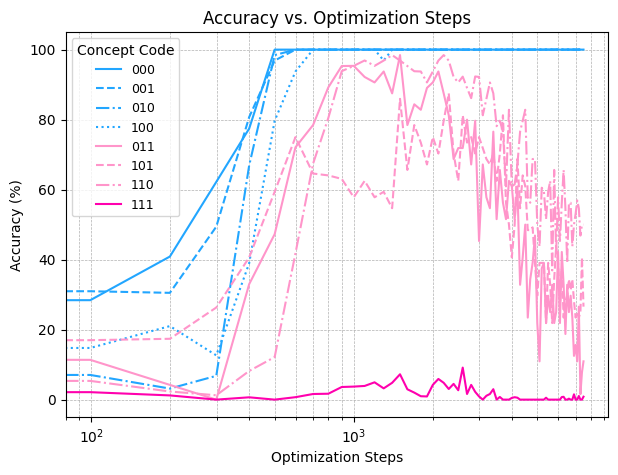

In [8]:
plt.figure(figsize=(7, 5))

for concept_code in line_styles.keys():
    steps = np.array(cont_data[concept_code]["steps"])
    accuracies = np.array(cont_data[concept_code]["accuracies"])

    color, linestyle = line_styles.get(concept_code, ("gray", "solid"))
    plt.plot(steps, accuracies, linestyle=linestyle, color=color, label=concept_code)

plt.xscale("log")
plt.xlabel("Optimization Steps")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs. Optimization Steps")

plt.legend(title="Concept Code", fontsize=9)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()


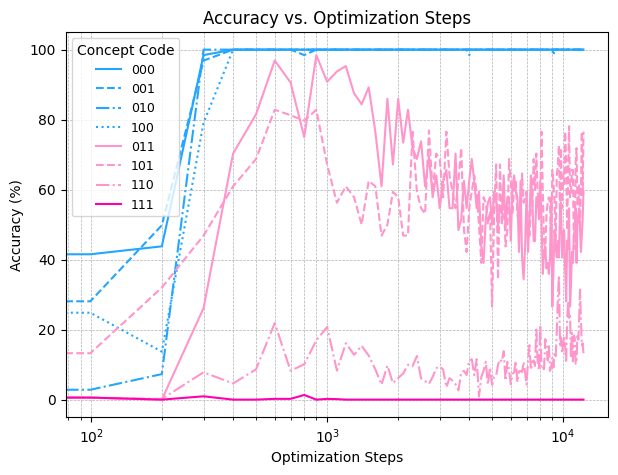

In [13]:
plt.figure(figsize=(7, 5))

for concept_code in line_styles.keys():
    steps = np.array(cont_data_common[concept_code]["steps"])
    accuracies = np.array(cont_data_common[concept_code]["accuracies"])

    color, linestyle = line_styles.get(concept_code, ("gray", "solid"))
    plt.plot(steps, accuracies, linestyle=linestyle, color=color, label=concept_code)

plt.xscale("log")
plt.xlabel("Optimization Steps")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs. Optimization Steps")

plt.legend(title="Concept Code", fontsize=9)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()
